# Linear Elasticity Problem

Description

In [1]:
!pip install --force-reinstall --no-cache-dir git+https://github.com/Violandree/PODCNF.git

  Cloning https://github.com/Violandree/PODCNF.git to /tmp/pip-req-build-y9pxwg2c
  Running command git clone --filter=blob:none --quiet https://github.com/Violandree/PODCNF.git /tmp/pip-req-build-y9pxwg2c
  Resolved https://github.com/Violandree/PODCNF.git to commit 8fdf16c62e3dcf076aff8e6f06e5de754d9a38d7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 1.2 MB/s eta 0:00:00
  Created wheel for POD-CNF---Andrea-Violante: filename=pod_cnf_andrea_violante-1.0-py3-none-any.whl size=24183 sha256=852971c83bd3e2950385641247358ea1e34fd5390a2264dc40bef3738ff0af39
  Stored in directory: /tmp/pip-ephem-wheel-cache-5545s7ia/wheels/49/c0/b6/733bfbf2151c90f1355079756775b4625d57003884ca7f5a2d
Successfully built POD-CNF---Andrea-Violante
  Attempting uninstall: absl-py
    Found existing installation: absl-py 2.4.0
    Uninstalling absl-py-2.4.0:
      Succ

In [2]:
!pip install -U https://github.com/PythonOT/POT/archive/master.zip

  Using cached https://github.com/PythonOT/POT/archive/master.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
!pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git

  Cloning https://github.com/NicolaRFranco/dlroms.git to /tmp/pip-req-build-b61qhyyz
  Running command git clone --filter=blob:none --quiet https://github.com/NicolaRFranco/dlroms.git /tmp/pip-req-build-b61qhyyz
  Resolved https://github.com/NicolaRFranco/dlroms.git to commit c80bc11584e8a9be566cdec45829177ad83f554a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
# Import core built-in libraries first
import os
import logging
import random
import itertools
import warnings

# To import data and models
import gdown

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Set seed for reproducibility
SEED = 42

# Set seeds for random number generators in NumPy and Python
import numpy as np
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torch.distributions import Normal

# Device configuration
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.linalg import svd

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.10.0+cpu
Device: cpu


In [39]:
from PODCNF.DataGeneration.LinearElasticityData import *
from PODCNF.Loader import LoadData, make_loader
from PODCNF.NFmodel import NormalizingFlow, sample_same_mu
from PODCNF.Training import full_train, tuning_parameters
from PODCNF.PlottingLinearElasticity import plot_data, plot_conditional_same_mu, plot_marginal_conditional_density, plot_2D_conditional_density, svd_residuals, analyze_bases_variation_main, Likelihood_Comparison_Main
from PODCNF.Utils import sliced_Wasser, Wasser_dist

# Elasticity Data Generation

In [6]:
n_samples = 6400

General description: With this problem we would like to analyse the deformation of square blaock hit by a spherical object with a given mass and radius. What is unkown on this problem is the itnernal structure of the block material that is hit. What we know is that inside there is a soft material and one that is more hard. These two materials are linearly separated and the slope of this line that diveides teh two materials is characterized by a an angle theta that it is the true parameter unknown.
Even we have a numerical solver, given the randomicity of theta we can get multiple out conditionally to a given mass and diameter (delta). For this reason we want to model its conditional probability that is more informative than the simple numerical prediction.

The numerical produce a deformation u and three other quantities:

- mass: a random mass in the interval `m_in = np.random.rand() + 1`
- delta: a random diameter in the interval `d_in = np.random.rand()*0.1 + 0.15`
- g: that is the linear field that separates the two materials

The solution u represents the deformation of the block both in x and y, so the output is 2-dim.
Due to the randomicity of theta each time we sample from the Numerical Solver we obtain different outputs no matter we give in input the same value for mass and delta. Due to this latent variable that in practice it is something that we don't know we obtain multiple output for same values of mass and delta that induced the computation of a probability distribution.

## Getting data

We begin by sampling 4800 data, this would be the numerosity of the training set $N_{train} = 4800$ and $N_{val} = 1280$ for the validation set, for a totale of 6080 data. After we will decrease the numerosity to verify the ecfficientness of our generative modells w. r. to some measure

About the dimensionality:

- The latent space made of the unkkwon quantity is given by theta so it has dimension 1
- The parameters on which we condition are the two values mass and delta, so it has dimensione 2
- The solution lives in `Vh.dim() = 1922` but ew have a solution in x and y. In fact, the block is 31x31 = 961 and we have to duble for a solution in x and y, so we have 961x2 = 1922

For efficient computation all the data are taken as tensor and moved to the device.

In [ ]:
n_samples = 1

# Option:
# 0 = Gaussian Process
# 1 = Linear
option = 1

mass = torch.zeros(n_samples, 1)
delta = torch.zeros(n_samples, 1)
theta = torch.zeros(n_samples, 1)
g = torch.zeros(n_samples, V_lam.dim())
u = torch.zeros(n_samples, Vh.dim())

for i in range(n_samples):

    # Random mass and delta
    m_in = np.random.rand() + 1
    d_in = np.random.rand()*0.1 + 0.15

    # Stochastic seed
    seed_in = np.random.randint(0, 2**32 - 1)

    mass_data, delta_data, g_data, u_data, theta_data = FOMsampler(
        seed_in, m_in, d_in, option
    )

    mass[i] = torch.tensor(mass_data)
    delta[i] = torch.tensor(delta_data)
    u[i,:] = torch.tensor(u_data)
    g[i,:] = torch.tensor(g_data)
    theta[i] = torch.tensor(theta_data)

In [ ]:
index = np.random.randint(0, n_samples - 1)
plot_data(g[index], u[index], Vh, V_lam)

In [ ]:
data_to_save = {
    'mass': mass,
    'delta': delta,
    'g_data': g,
    'u_data': u,
    'theta': theta
}

# filename = "data_linear_density_2pi.pt"
filename = "data_test.pt"
torch.save(data_to_save, filename)

print(f"Data saved in '{filename}'")

In [ ]:
import shutil

os.makedirs(drive_path, exist_ok=True)

# source_file = "data_linear_density_2pi.pt"
source_file_test = "data_test.pt"
destination_file = os.path.join(drive_path, 'Elastic_Problem_Results',source_file_test)
shutil.copy(source_file_test, destination_file)

## Load Data

Here we could observe a sample from the data that we have generated, in the left side we have the random structure of the material and at the left we have a possible deformation given a specific mass and delta

In [15]:
%%capture

# Data
filename = "data_linear_density_2pi.pt"
gdown.download(id = "1NYiXCqCNLhB87o3OlAav6YfiAO9qoBnM", quiet=True, output = filename)
loaded_data = torch.load(filename)

# Test Data
filenameTest = "data_test.pt"
gdown.download(id = "1GtBiXTjdzCFM16KTTMiAD7aiqNcu-ggc", quiet=True, output = filenameTest)
loaded_data_test = torch.load(filenameTest)

In [16]:
mass = loaded_data['mass']
delta = loaded_data['delta']
g = loaded_data['g_data']
u = loaded_data['u_data']

In [17]:
mass_TEST = loaded_data_test['mass']
delta_TEST = loaded_data_test['delta']
theta_TEST = loaded_data_test['theta']
g_TEST = loaded_data_test['g_data']
u_TEST = loaded_data_test['u_data']

In [18]:
print(f"mass shape: {mass.shape}")
print(f"delta shape: {delta.shape}")
print(f"g shape: {g.shape}")
print(f"u shape: {u.shape}")

mass shape: torch.Size([6400, 1])
delta shape: torch.Size([6400, 1])
g shape: torch.Size([6400, 1800])
u shape: torch.Size([6400, 1922])


In [19]:
mu = torch.cat((mass, delta), 1)
mu_TEST = torch.cat((mass_TEST, delta_TEST), 1)
print(f"mu: {mu_TEST.shape}")

mu: torch.Size([6400, 2])


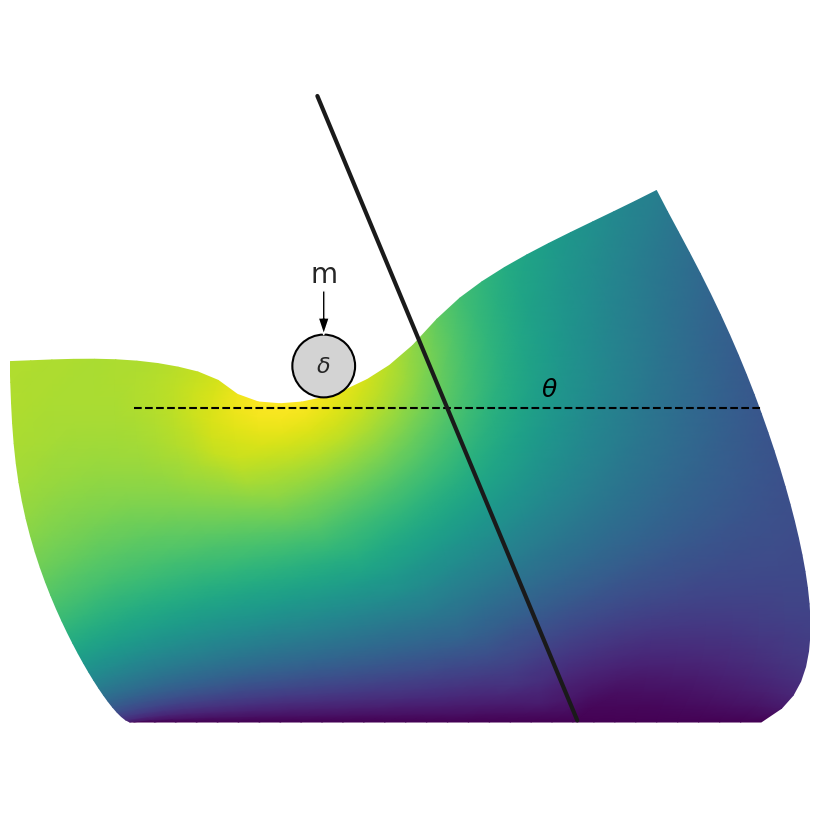

In [22]:
import logging
logging.getLogger("FFC").setLevel(logging.WARNING)

n_samples = mass.shape[0]
index = np.random.randint(0, n_samples - 1)
plot_data(g_TEST[index], u_TEST[index], Vh, V_lam, mu_TEST[index], theta_TEST[index])

In [41]:
# Da mettere in libreria
def visualize_elasticity_variability(mass_val, delta_val, Vh):

    n_plots = 4
    option = 1

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes_flat = axes.flatten()

    for i in range(n_plots):
        ax = axes_flat[i]
        plt.sca(ax)

        seed_in = np.random.randint(0, 2**32 - 1)
        _, _, _, u_data, theta_rad = FOMsampler(seed_in, mass_val, delta_val, option=option)

        if isinstance(theta_rad, (np.ndarray, list)):
             theta_deg = math.degrees(theta_rad.item())
        else:
             theta_deg = math.degrees(theta_rad)

        u_func = fe.Function(Vh)
        if hasattr(u_data, 'detach'):
            u_vec = u_data.detach().cpu().numpy()
        else:
            u_vec = u_data
        u_func.vector()[:] = u_vec

        fe.plot(u_func, warp = "True", cmap="jet")

        ax.set_aspect('equal')
        ax.set_xlim(-0.2, 1.2)
        ax.set_ylim(-0.05, 1.05)

        ax.set_title(f"$\\theta = {theta_deg:.1f}^\\circ$\n$\mu = [{mass_val:.2f}, {delta_val:.2f}]$", fontsize=14)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.subplots_adjust(hspace=0.4, wspace=0.2)

    plt.show()

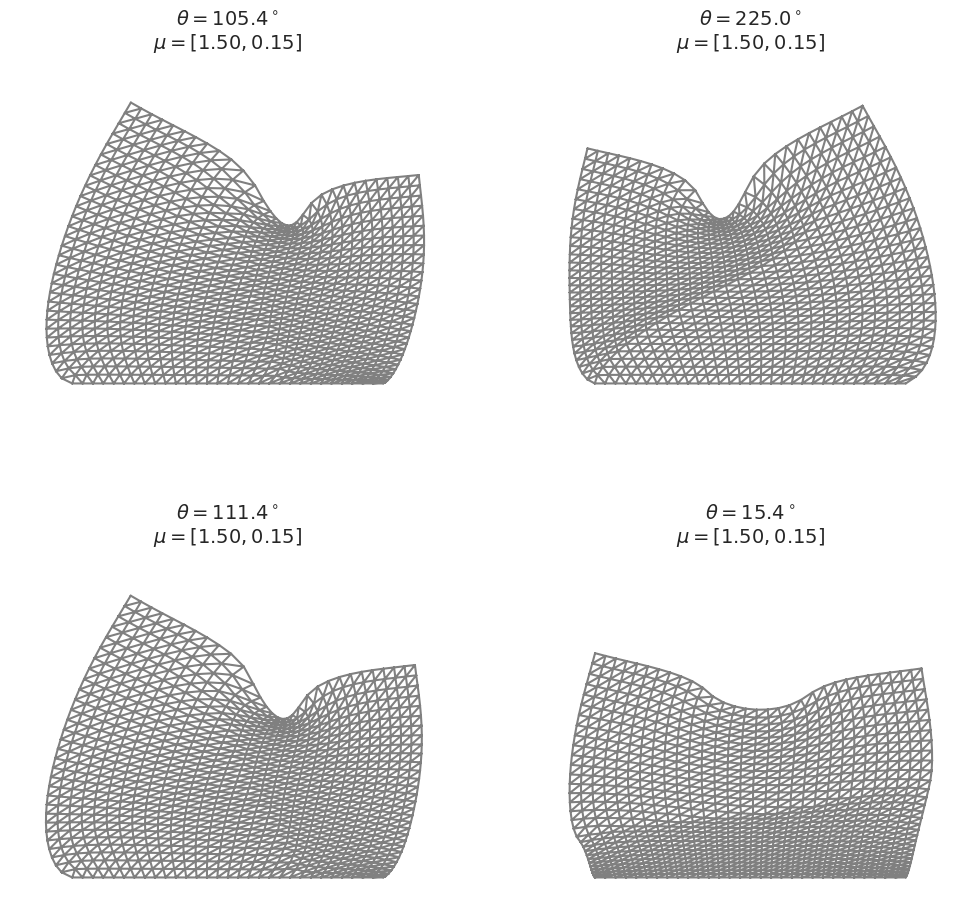

In [42]:
mass_input = np.random.rand() + 1
delta_input = np.random.rand()*0.1 + 0.15
visualize_elasticity_variability(mass_input, delta_input, Vh)

## SVD

To train our generative model of course it is not possbile to use all the dimensions (1922), for this we represent our solution in a Low-dimensional space. So then what the NF will learn will be the probability distribution of c|mass,delta. Where c are the coefficients given by the SVD obtained with projection matrix V. This solves the computation part. After that will be sufficient to re-project our coefficients into the high-dimensional space to obtaing for instance graphical representation and so on.

For the SVD I've used N_train to compute the SVD and then I've evaluated the performances on the validation set

In [43]:
from scipy.linalg import svd
ntrain = int(n_samples * 0.75)
nval = int(ntrain + n_samples * 0.2)
X, s, _ = svd(u[:ntrain].T, full_matrices = False)

In [44]:
s_array = np.array(s)
s_percentage = s_array / np.sum(s_array, keepdims=True)

Here the cumulative variance given 20 basis as an example

In [45]:
n_basis = 20
cum_s = np.cumsum(s_percentage[:n_basis])
cum_s

array([0.6390432 , 0.8280114 , 0.90399534, 0.9177873 , 0.9284254 ,
       0.93578935, 0.9422987 , 0.9484293 , 0.95227444, 0.95594704,
       0.95854115, 0.96088195, 0.96308446, 0.9647723 , 0.96617174,
       0.967498  , 0.9685986 , 0.9696048 , 0.97056013, 0.9714681 ],
      dtype=float32)

The projection error comptuted as follow:
```
V = X[:, :n_basis]
errors = np.linalg.norm(u[ntrain:nval, :] - u[ntrain:nval, :] @ V @ V.T, axis = 1)/np.linalg.norm(u[ntrain:nval], axis = 1)
```
Hows us that it is around 0.36% for 20 basis a good result

In [46]:
V = X[:, :n_basis]
errors = np.linalg.norm(u[ntrain:nval, :] - u[ntrain:nval, :] @ V @ V.T, axis = 1)/np.linalg.norm(u[ntrain:nval], axis = 1)

print("Basis projection error: %s." % num2p(errors.mean()))

Basis projection error: 0.36%.


In [47]:
c = u @ V

In the residual plot we could observe a uniformly spread random cloud for each cylinder. Each plot represent the relative error defined in this way:
```
residuals = u - u_rec
u_norms = np.linalg.norm(u, axis=1)
error_norms = np.linalg.norm(residuals, axis=1)
relative_errors = np.divide(error_norms, u_norms, out=np.zeros_like(error_norms), where=u_norms!=0)
```
Basically we measure the distance between the true u and the reconstructed one, we take the norm and divided it by u_norms.
We don't see any strange behaviour so we can assume that there is no bias threw certain specific configuration.

For what concerns the Mean Absolute Reconstruction Error for 20 basis: $|u_{true} - u_{rec}|$
We could see that the error is centerd around the cylinder.

Mean Relative Error: 0.3616%
Max Relative Error:  0.6203%


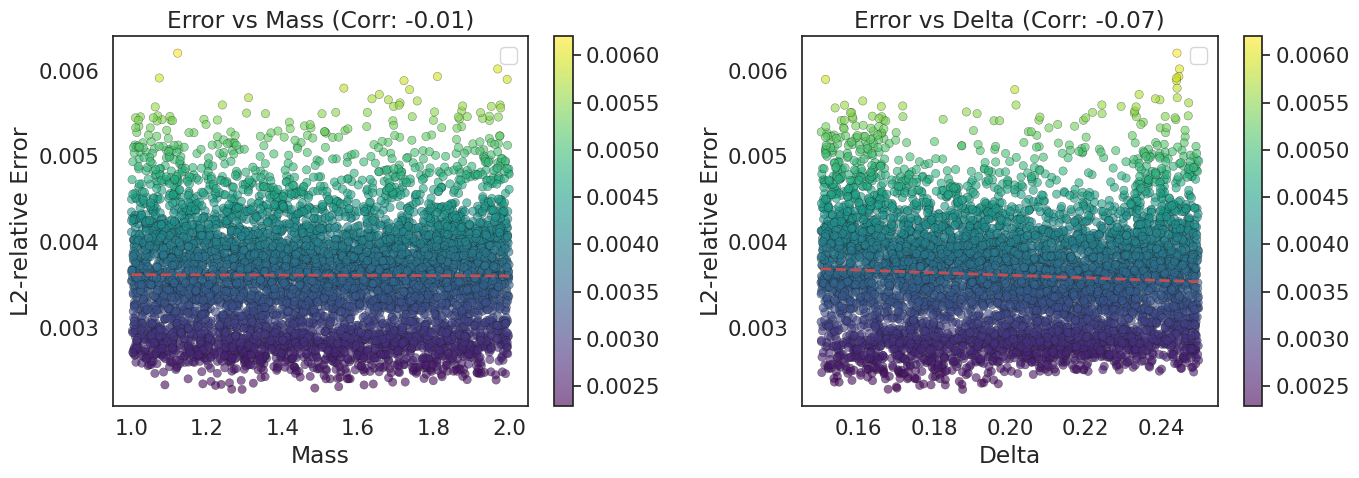

In [48]:
mean_field = svd_residuals(u, V, mu, Vh)

DEBUG:UFL_LEGACY:Blocks of each mode: 
  1	full


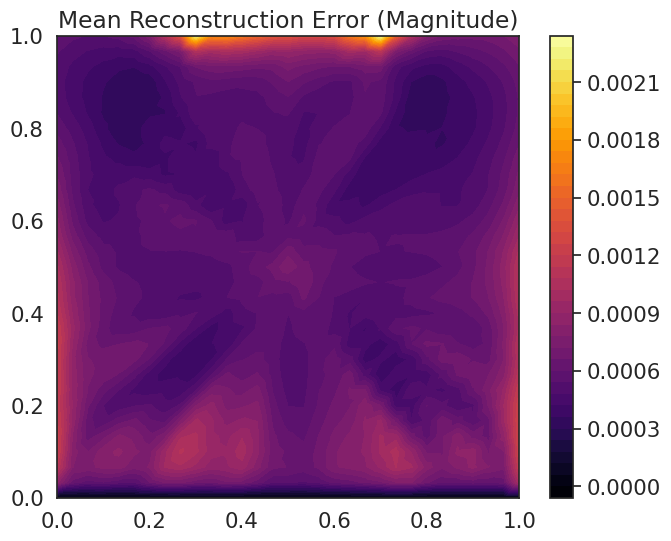

In [49]:
plt.figure(figsize=(8, 6))

error_function = Function(Vh)
error_function.vector()[:] = mean_field

mesh = Vh.mesh()
Vs = FunctionSpace(mesh, 'CG', 1)
magnitude_expression = sqrt(inner(error_function, error_function))
magnitude_function = project(magnitude_expression, Vs)
c_plot = plot(magnitude_function, cmap='inferno')

plt.title("Mean Reconstruction Error (Magnitude)")
plt.colorbar(c_plot)
plt.show()

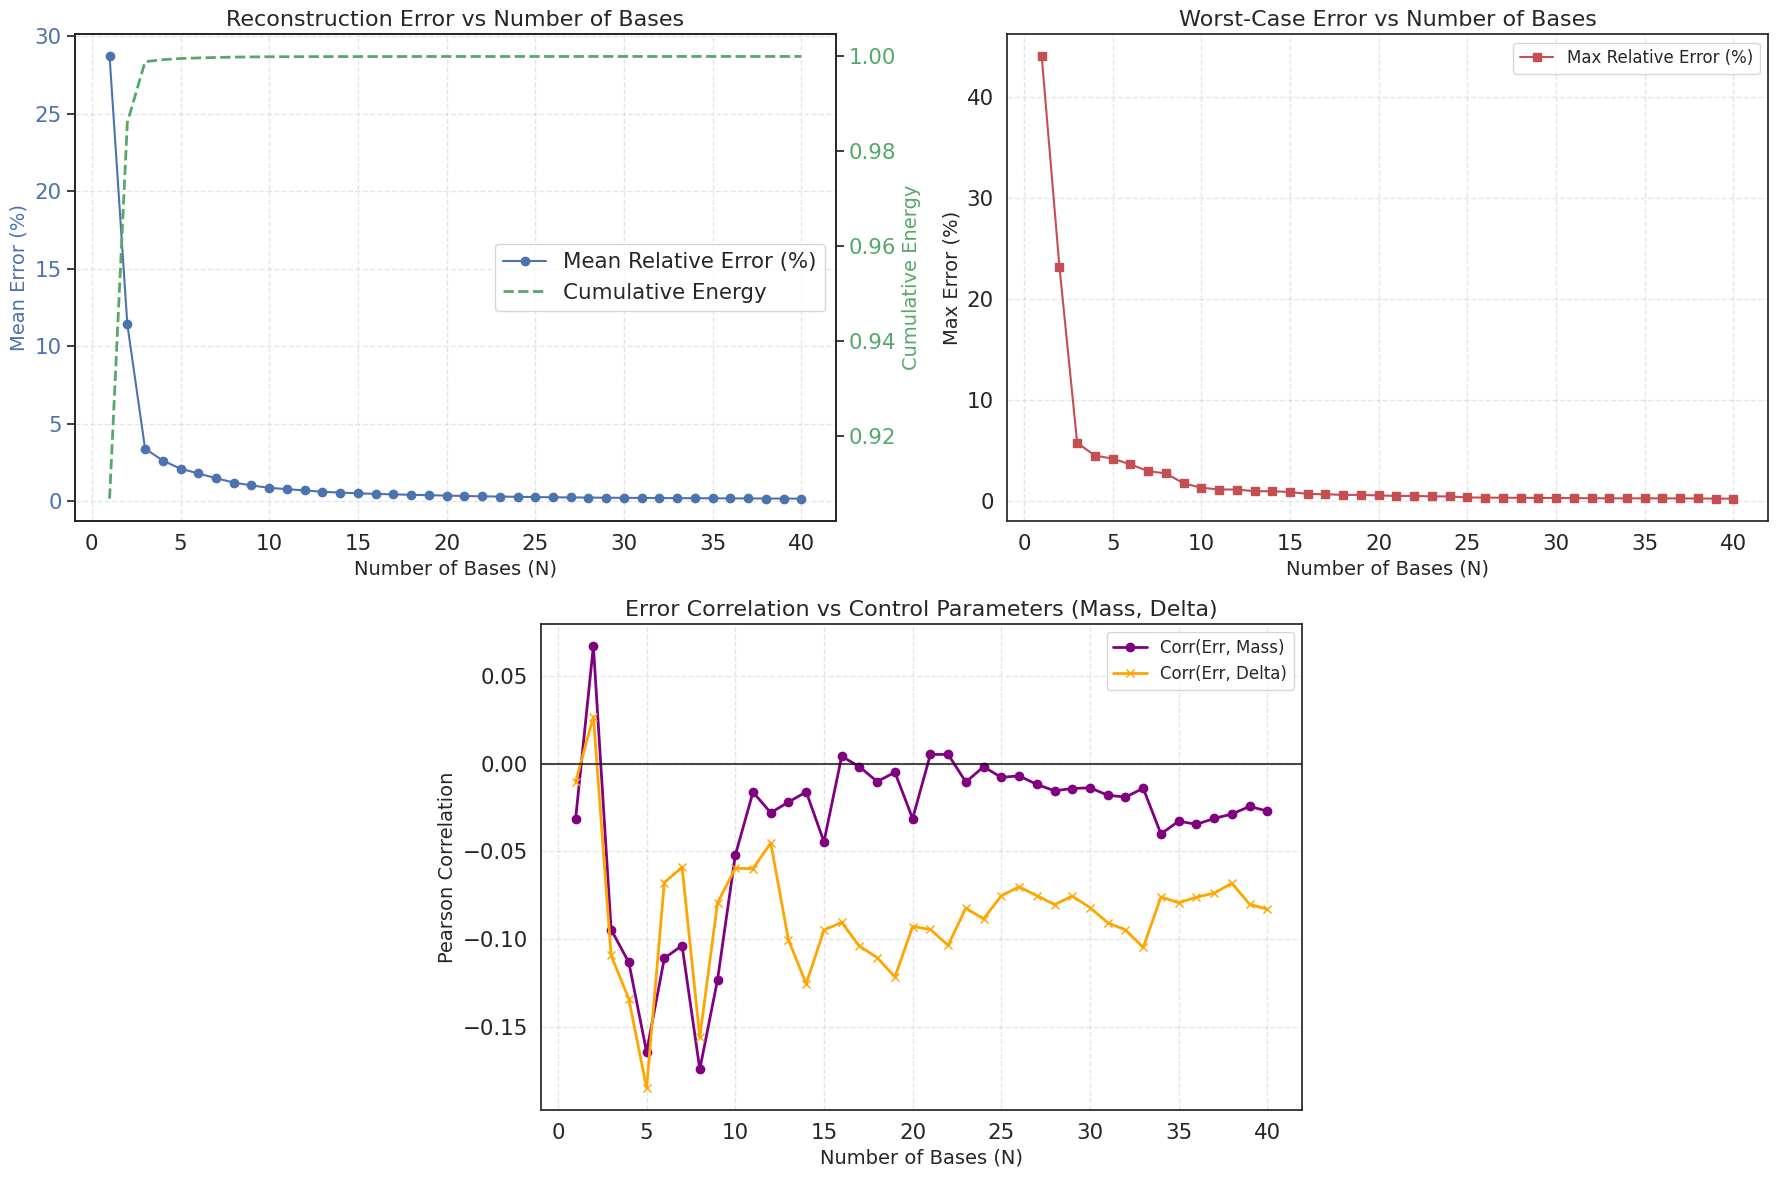

In [50]:
analyze_bases_variation_main(u, mu, n_bases_list=range(1, 41))

This figure presents a convergence analysis of the Proper Orthogonal Decomposition (POD) regarding reconstruction accuracy and parameter sensitivity.1. Mean Reconstruction Error & Cumulative Energy (Left Panel)This plot demonstrates the efficiency of the reduced-order model (ROM).Rapid Convergence: The mean relative error (blue line) exhibits a sharp exponential decay. The error drops from $\sim28\%$ to below $1\%$ within the first 10 bases.Energy Capture: The cumulative energy (green dashed line) saturates very quickly. The first few modes capture over 99% of the system's energy.At $N=20$: The curve has completely flattened (asymptotic behavior). Adding more bases beyond 20 yields negligible improvement in mean accuracy, confirming that 20 modes are more than sufficient to capture the relevant physics.2. Worst-Case Error (Center Panel)While the mean error is low, this plot ensures robustness by tracking the maximum error across the validation set.The worst-case error follows a similar decay trend to the mean error.At $N=20$: The maximum error is extremely low (close to $0\%$). This indicates that the basis set is robust: there are no "outlier" samples (specific combinations of Mass/Delta) that the model fails to reconstruct accurately.3. Error Correlation with Parameters (Right Panel)This plot analyzes if the reconstruction error is systematically biased by the physical parameters (Mass and Delta).Interpretation: Ideally, we want the correlation to be close to zero. A high correlation would imply the model works well for some parameter ranges but poorly for others (systematic bias).Initial Fluctuations ($N < 10$): In the early modes, there are strong fluctuations, suggesting the error is highly sensitive to the physics of the problem.At $N=20$:The correlation with Mass (blue dots) oscillates around zero, indicating the error is effectively decoupled from the mass.The correlation with Delta (orange crosses) stabilizes at a low negative value ($\approx -0.1$). This slight correlation is statistically acceptable and suggests no strong systematic bias.Conclusion: Why $N=20$ is the optimal choiceSelecting $N=20$ is a conservative and robust choice. While the energy criterion (>99%) is satisfied much earlier (around $N=5$), keeping 20 modes ensures:High-Fidelity Reconstruction: Both mean and max errors are practically zero.Parameter Independence: The reconstruction quality is consistent across the entire parameter space of Mass and Delta, as shown by the low correlations.Stability: You are well into the "flat" region of the convergence curve, avoiding the risk of underfitting complex flow features.

## Prepare data

In [51]:
BATCH_SIZE = 64

n_train = int(n_samples * 0.75)
n_val = int(n_train + n_samples * 0.2)
n_test = int(n_samples * 0.05)

shuffle = True
drop_last = False

# norm_scaler = None # No normalization
norm_scaler = True # StandardScaler()
# norm_scaler = False # MinMaxScaler()

print(f"n_train: {n_train}")
print(f"n_val: {n_val}")
print(f"n_test: {n_test}")

n_train: 4800
n_val: 6080
n_test: 320


In [52]:
if norm_scaler == None:
    train_loader, val_loader, test_loader = LoadData(mu, c,
                                                     n_train, n_val,
                                                     BATCH_SIZE,
                                                     norm_scaler,
                                                     shuffle, drop_last)
else:
    train_loader, val_loader, test_loader, mu_scaler, c_scaler = LoadData(mu, c,
                                                                          n_train, n_val,
                                                                          BATCH_SIZE,
                                                                          norm_scaler,
                                                                          shuffle, drop_last)

In [53]:
print(f"Mean - std (Train): {train_loader.dataset.data.mean()} - {train_loader.dataset.data.std()}")
print(f"Mean - std (Val): {val_loader.dataset.data.mean()} - {val_loader.dataset.data.std()}")
print(f"Mean - std (Test): {test_loader.dataset.data.mean()} - {test_loader.dataset.data.std()}")

Mean - std (Train): 2.1674416428307808e-10 - 1.000004768371582
Mean - std (Val): -0.004494399297982454 - 1.0075092315673828
Mean - std (Test): -0.01708870939910412 - 1.0051417350769043


In [54]:
dim_x = mu.shape[1]
dim_y = c.shape[1]

print(f"Dim parameter space: {dim_x}")
print(f"Dim data space: {dim_y}")

Dim parameter space: 2
Dim data space: 20


In [55]:
print(f"Number of workers: {train_loader.num_workers}")
print(f"Train shape: {train_loader.dataset.data.shape}")
print(f"Val shape: {val_loader.dataset.data.shape}")
print(f"Test shape: {test_loader.dataset.data.shape}")

Number of workers: 2
Train shape: torch.Size([4800, 22])
Val shape: torch.Size([1280, 22])
Test shape: torch.Size([320, 22])


# Training

In [ ]:
# Enable mixed precision training for GPU acceleration
if torch.cuda.is_available():
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
else:
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cpu'))

## Tuning hyperparameters

In [ ]:
lr = [1e-3, 5e-4]
num_flows = [16, 24, 32]
hidden_size = [256, 512]
hidden_depth = [1, 2]
wd = [1e-5, 1e-4]

tuning_epochs = 80

In [ ]:
# Folder where I'll save all the experiments
base_logs_dir = "tensorboard_hyperparam_run_2"
os.makedirs(base_logs_dir, exist_ok=True)
writer = SummaryWriter(base_logs_dir)

In [ ]:
%%time

%tensorboard --logdir {base_logs_dir}

best_hyperparams = tuning_parameters(train_loader, val_loader,
                                     lr, num_flows, hidden_size, hidden_depth, wd,
                                     tuning_epochs,
                                     dim_x, dim_y, device,
                                     base_logs_dir)

## Train the model

In [ ]:
model_save_path = '/content/model.pt'

# {'learning_rate': 0.001, 'num_flows': 16, 'hidden_size': 256, 'hidden_depth': 2, 'weight_decacy': 1e-05}

EPOCHS = 200
print_frequency = 10
patience = 20

# Hyperparameters
lr = 0.001 # best_hyperparams['learning_rate']
num_flows = best_hyperparams['num_flows']
hidden_size = best_hyperparams['hidden_size']
hidden_depth = best_hyperparams['hidden_depth']
wd = best_hyperparams['weight_decacy']

In [ ]:
print(f"Learning Rate: {lr}\nnum_flows: {num_flows}\nhidden_size: {hidden_size}")
print(f"Hidden Depth: {hidden_depth}\nweight_decay: {wd}")

In [ ]:
# Model definition
flow = NormalizingFlow(dim_x, dim_y, num_flows=num_flows, hidden_size=hidden_size, hidden_depth=hidden_depth, device=device).to(device)
print(flow)

In [ ]:
writer = SummaryWriter(logs_dir)

In [ ]:
%%time

%tensorboard --logdir {logs_dir}

full_train(
    EPOCHS,
    print_frequency,
    flow,
    train_loader,
    val_loader,
    lr,
    wd,
    patience,
    device,
    writer,
    model_save_path
)

## Save Model

Founded the following optimal parameters:

{'learning_rate': 0.001, 'num_flows': 16, 'hidden_size': 256, 'hidden_depth': 2, 'weight_decacy': 1e-05}

In [ ]:
MODEL_NAME = 'MODEL_64_NEW'
destination_folder = os.path.join(project_path, 'Stokes_Problem_Results')
save_path = os.path.join(destination_folder, MODEL_NAME)

torch.save(flow.state_dict(), save_path)

# Analysis

## Load Model

In [58]:
# {'learning_rate': 0.001, 'num_flows': 16, 'hidden_size': 256, 'hidden_depth': 2, 'weight_decacy': 1e-05}
MODEL_NAME = 'MODEL_64_NEW.pth'
gdown.download(id = "1Mv9opjkEMDQaLBQx07Fqvh_ItyefLsCl", quiet=True, output = MODEL_NAME)
loaded_model = torch.load(MODEL_NAME, map_location=device)

In [59]:
# Linear model
num_flows = 16
hidden_size = 256
hidden_depth = 2

NF_linear = NormalizingFlow(dim_x, dim_y, num_flows, hidden_size, hidden_depth, device).to(device)
NF_linear.load_state_dict(loaded_model)

<All keys matched successfully>

In [60]:
# Loaded Flow - Linear
flow = NF_linear

## Performance on a fixed $\mu$

In this chapter I'll go some analysis of the conditional dsitribution given a same $\mu$.

### Generating sample from $p(u|$$\mu$$)$ for a given $\mu$

First we select a value for $\mu$ from the test set, we scale it. Then, we use the sample method in our NF model to get the coefficient $c$ since our NF is trained over the low-representation. The sample method, as discussed in other chapters, takes in input $\mu$ and a sample from the base distribution, and threw the affine transformation we get a sample from the conditional distribution

In [61]:
test_index = 6353 # np.random.randint(n_val, n_samples) - Userai questo indice per le successive analisi
# Corresponding value for mu and g
mu_sele = mu_TEST[test_index - 1, :].numpy()
g_sele = g_TEST[test_index - 1, :]
theta_sele = theta_TEST[test_index - 1, :]
u_true = u_TEST[test_index -1, :]
print(f"mu_selected: {mu_sele}")
print(test_index)

mu_selected: [1.2044513 0.2187605]
6353


In [62]:
# u_rec: generated solution given a random mu

n_generations = 1000

u_rec = sample_same_mu(flow,
                       mu_sele, V,
                       device,
                       norm_scaler, mu_scaler, c_scaler,
                       n_generations)

The fact that we obtain a different solutions for the same value of $\mu$ si due to the fact each time we make a sample, we must sample a random value from the base dsitribution

In [64]:
# Da mettere in libreria
def plot_conditional_same_mu(n_generations,
                             g_sele, mu_sele,
                             u_true, u_rec,
                             V_lam, Vh,
                             theta=None):

    import dolfin as fe

    if torch.is_tensor(mu_sele): mu_val = mu_sele.detach().cpu().numpy().flatten()
    else: mu_val = np.array(mu_sele).flatten()

    u_true_func = fe.Function(Vh)
    if torch.is_tensor(u_true): u_t_data = u_true.detach().cpu().numpy().flatten()
    else: u_t_data = np.array(u_true).flatten()
    u_true_func.vector().set_local(u_t_data)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title(f"True solution (Deformation)\n($m={mu_val[0]:.2f}, \\delta={mu_val[1]:.2f}$)", fontsize=16)

    mesh = Vh.mesh()
    original_coords = mesh.coordinates()
    cells = mesh.cells()

    u_vals = u_true_func.compute_vertex_values(mesh)
    N = mesh.num_vertices()
    u_x, u_y = u_vals[:N], u_vals[N:]

    def_x = original_coords[:, 0] + u_x
    def_y = original_coords[:, 1] + u_y
    u_mag = np.sqrt(u_x**2 + u_y**2)

    ax.tripcolor(def_x, def_y, cells, u_mag, cmap='viridis', shading='gouraud')
    max_y_orig = np.max(original_coords[:, 1])
    top_nodes = np.where(np.abs(original_coords[:, 1] - max_y_orig) < 1e-5)[0]
    mid_x = (np.max(original_coords[:, 0]) + np.min(original_coords[:, 0])) / 2.0
    top_center_idx = top_nodes[np.argmin(np.abs(original_coords[top_nodes, 0] - mid_x))]

    def_top_x = def_x[top_center_idx]
    def_top_y = def_y[top_center_idx]

    ax.plot([0, 1], [0.5, 0.5], color='black', linestyle='--', linewidth=1.5, zorder=10)

    if theta is not None:
        try:
            theta_val = theta.item() if torch.is_tensor(theta) else theta
            x_line = np.linspace(0, 1, 100)
            y_line = 0.5 + (x_line - 0.5) * np.tan(theta_val)
            mask_line = (y_line >= 0) & (y_line <= 1)

            if np.any(mask_line):
                ax.plot(x_line[mask_line], y_line[mask_line], 'k-', linewidth=3.0, zorder=11)
            ax.text(0.65, 0.52, r'$\theta$', fontsize=18, color='black', zorder=15)
        except:
            pass

    domain_width = np.max(original_coords[:, 0]) - np.min(original_coords[:, 0])
    R = 0.05 * domain_width if domain_width > 0 else 0.05

    ball_x = def_top_x
    ball_y = def_top_y + R

    circle = plt.Circle((ball_x, ball_y), R, color='lightgray', ec='black', lw=1.5, zorder=20)
    ax.add_patch(circle)
    ax.text(ball_x, ball_y, '$\delta$', fontsize=16, ha='center', va='center', zorder=21)

    ax.annotate('m',
                xy=(ball_x, ball_y + R),
                xytext=(ball_x, ball_y + 2.5 * R),
                arrowprops=dict(facecolor='black', shrink=0.0, width=2, headwidth=8),
                fontsize=20, ha='center', va='bottom', zorder=20)

    ax.set_xlim(np.min(def_x) - R, np.max(def_x) + R)
    ax.set_ylim(np.min(def_y), np.max(def_y) + 3.5 * R)
    ax.set_aspect('equal')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Generated samples
    print(f"{n_generations} Generated samples:")

    cols = int(math.ceil(math.sqrt(n_generations)))
    rows = int(math.ceil(n_generations / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))

    if rows == 1 and cols == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    for i in range(n_generations):
        ax_gen = axes_flat[i]
        plt.sca(ax_gen)

        if isinstance(u_rec, list):
            s_tens = u_rec[i]
        else:
            s_tens = u_rec[i]

        u_gen_func = fe.Function(Vh)
        if torch.is_tensor(s_tens): s_data = s_tens.detach().cpu().numpy().flatten()
        else: s_data = np.array(s_tens).flatten()
        u_gen_func.vector().set_local(s_data)

        u_vals_gen = u_gen_func.compute_vertex_values(mesh)
        u_x_gen, u_y_gen = u_vals_gen[:N], u_vals_gen[N:]

        def_x_gen = original_coords[:, 0] + u_x_gen
        def_y_gen = original_coords[:, 1] + u_y_gen
        u_mag_gen = np.sqrt(u_x_gen**2 + u_y_gen**2)

        ax_gen.tripcolor(def_x_gen, def_y_gen, cells, u_mag_gen, cmap='viridis', shading='gouraud')
        ax_gen.set_xlim(np.min(def_x_gen), np.max(def_x_gen))
        ax_gen.set_ylim(np.min(def_y_gen), np.max(def_y_gen))
        ax_gen.set_aspect('equal')
        ax_gen.axis('off')

    for i in range(n_generations, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.tight_layout(pad=0)
    plt.show()

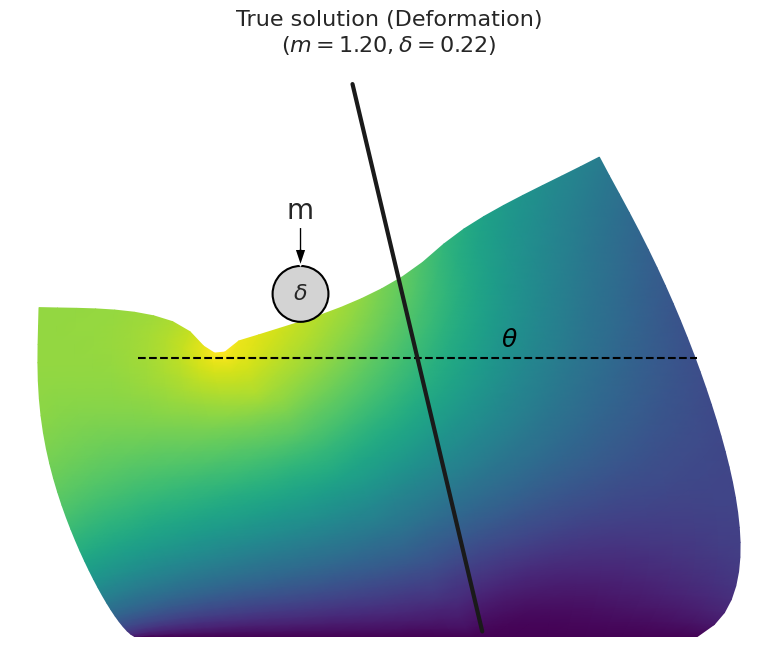

4 Generated samples:


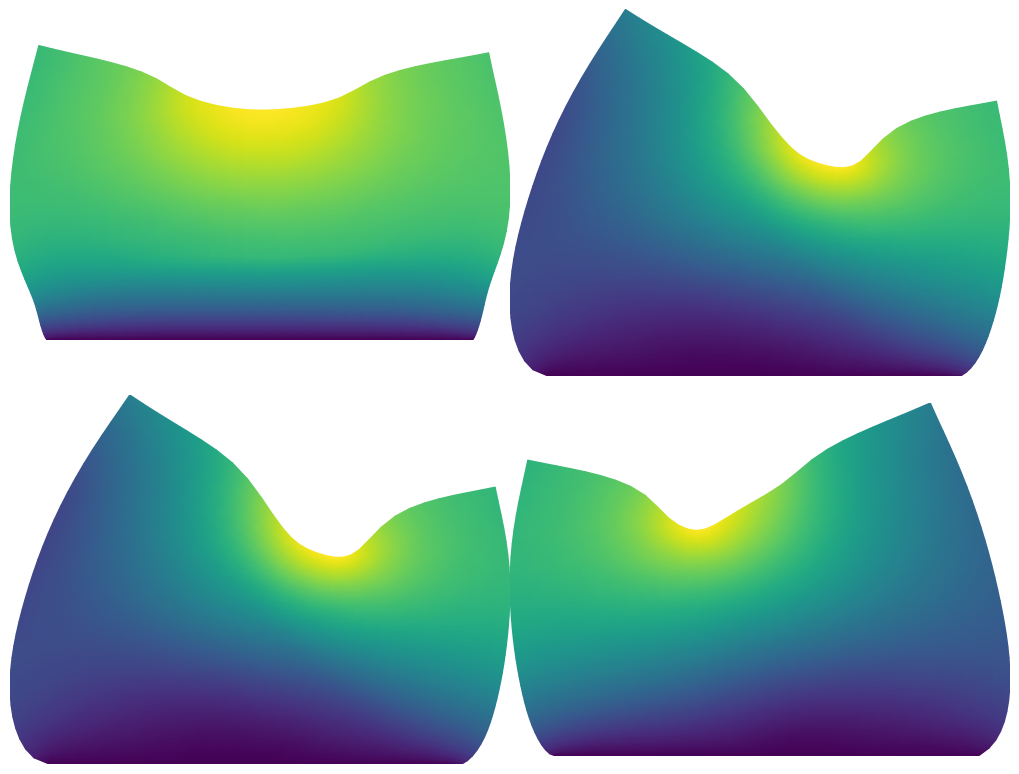

In [66]:
ii = np.random.randint(0, n_generations - 9)
plot_conditional_same_mu(4,
                         g_sele, mu_sele,
                         u_true, u_rec[ii:ii+9],
                         V_lam, Vh,
                         theta = theta_sele)

### Likelihood Comparison on a same $\mu_0$

In [ ]:
# mu_sele: selected mu
n_replicas = 1000

u_rec_0 = sample_same_mu(flow,
                         mu_sele, V, device,
                         norm_scaler, mu_scaler, c_scaler,
                         n_replicas)

In [ ]:
# Wasserstain ditsance tra i dati reali ottenuti per un dato mu e i dati generati
# dal modello per lo stesso valore di mu. Valore basso di Wasserstain distance
# implica che i dati generati con NF distano poco dalla distribuzione vera
w2_dist = Wasser_dist(u_true.reshape(1,-1), u_rec_0)
print(f"Exact Wasserstein-2 Distance (W_2): {w2_dist:.4f}")

Exact Wasserstein-2 Distance (W_2): 4.5552


In [ ]:
# Wasserstain disatnce for each dimension
DIM = Vh.dim()
WD = torch.zeros(DIM)
for i in range(DIM):
    WD[i] = Wasser_dist(u_true[i].reshape(-1,1), u_rec_0[:, i].reshape(-1,1))

In [ ]:
# Wasserstain distance for eache couple dimension, x and y
WD_2 = torch.zeros(DIM)
DIM_mezzi = DIM // 2
for i in range(DIM // 2):
    WD_2[2*i:2*i+2] = Wasser_dist(u_true[2*i:2*i+2].reshape(-1,1),
                          u_rec_0[:, [2*i, 2*i+1]].reshape(-1,1))

In [ ]:
print(torch.mean(WD))
print(torch.mean(WD_2))

tensor(0.0847)
tensor(0.0888)


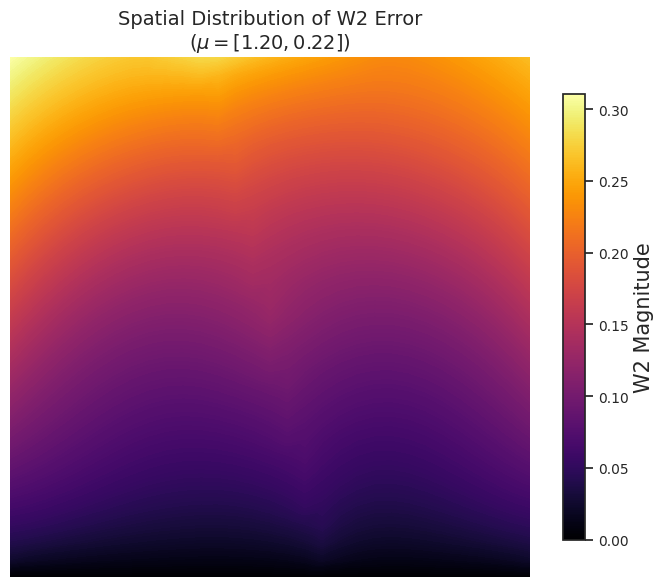

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as colors

vals = np.array(mu_sele).flatten()
mu_str = ", ".join([f"{x:.2f}" for x in vals])

wd_data = WD.detach().cpu().numpy()
degree = Vh.ufl_element().degree()
mesh = Vh.mesh()

Vh_scalar = fe.FunctionSpace(mesh, 'CG', degree)
wd_reshaped = wd_data.reshape(-1, 2)
data_to_plot = np.linalg.norm(wd_reshaped, axis=1)

WD_func = fe.Function(Vh_scalar)
WD_func.vector()[:] = data_to_plot.flatten()

plt.figure(figsize=(7, 6))
ax = plt.gca()

c = fe.plot(WD_func, cmap='inferno')

vmin = data_to_plot.min()
vmax = data_to_plot.max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap='inferno', norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, shrink=0.85)

cbar.set_label('W2 Magnitude', fontsize=15)
cbar.ax.tick_params(labelsize=10)

# Titolo e assi con font controllati
plt.title(f"Spatial Distribution of W2 Error\n($\mu=[{mu_str}]$)", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)

plt.tight_layout()
plt.show()

We could also obtain the optimal solution w.r. to the L2-distance. To see if inside the sample that I've generated with the NF there is inside a solution that is near to the true one

In [ ]:
l2 = L2(Vh)
clc()
l2dists = l2(u_true-u_rec_0) # all the distances between the true solution and the best one
u_best = u_rec_0[l2dists.argmin()] # select the one with the smallest l2-dist

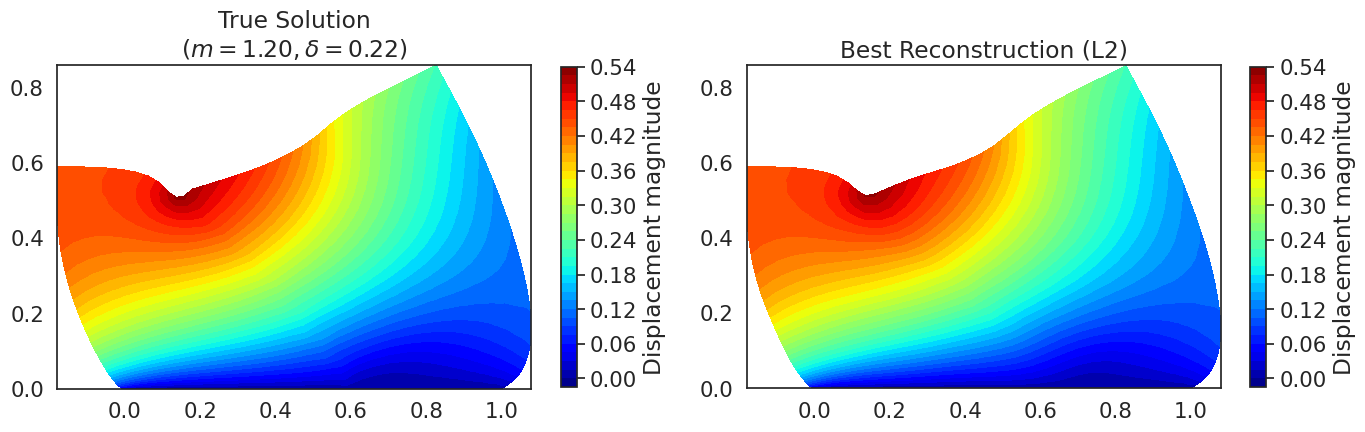

In [ ]:
# Runna prima SVD altrimenti non funzia
import dolfin as df

if torch.is_tensor(u_true):
    u0_data = u_true.detach().cpu().numpy().flatten()
else:
    u0_data = np.array(u_true).flatten()

if torch.is_tensor(u_best):
    u_best_data = u_best.detach().cpu().numpy().flatten()
else:
    u_best_data = np.array(u_best).flatten()

if torch.is_tensor(mu_sele):
    mu_val = mu_sele.detach().cpu().numpy().flatten()
else:
    mu_val = np.array(mu_sele).flatten()

func_true = df.Function(Vh)
func_true.vector().set_local(u0_data)

func_best = df.Function(Vh)
func_best.vector().set_local(u_best_data)

plt.figure(figsize=(14, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.set_title(f"True Solution\n($m={mu_val[0]:.2f}, \delta={mu_val[1]:.2f}$)")

mesh = Vh.mesh()
original_coords = mesh.coordinates().copy()

try:
    df.ALE.move(mesh, func_true)
    u_mag = df.sqrt(df.dot(func_true, func_true))
    V_scal = df.FunctionSpace(mesh, 'CG', 1)
    mag_plot = df.project(u_mag, V_scal)
    c1 = df.plot(mag_plot, cmap='jet')
    plt.colorbar(c1, ax=ax1, shrink=0.7, label='Displacement magnitude')
except Exception:
    df.plot(func_true, mode='displacement')
finally:
    mesh.coordinates()[:] = original_coords

ax2 = plt.subplot(1, 2, 2)
ax2.set_title("Best Reconstruction (L2)")

try:
    df.ALE.move(mesh, func_best)
    u_mag = df.sqrt(df.dot(func_best, func_best))
    V_scal = df.FunctionSpace(mesh, 'CG', 1)
    mag_plot = df.project(u_mag, V_scal)
    c2 = df.plot(mag_plot, cmap='jet')
    plt.colorbar(c2, ax=ax2, shrink=0.7, label='Displacement magnitude')
except Exception:
    df.plot(func_best, mode='displacement')
finally:
    mesh.coordinates()[:] = original_coords

plt.tight_layout()
plt.show()

$$\frac{||u(x)-u_{best}(x)||}{||u(x) - u_{mean}(x)||}$$

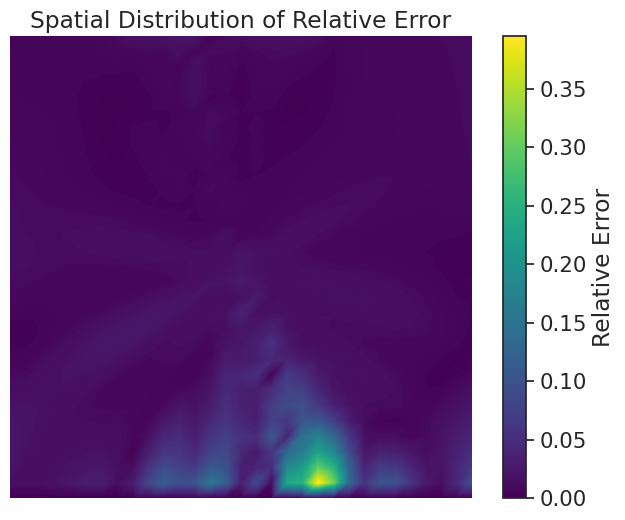

In [ ]:
# u_true: treue solution
# u_best: optimal solution
# u_mean: mean over the all dataset

mesh = Vh.mesh()
degree = Vh.ufl_element().degree()
Vscalar = fe.FunctionSpace(mesh, 'CG', degree)

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x

u_true_np = to_numpy(u_true)
u_best_np = to_numpy(u_best)
u_mean_np = to_numpy(u.mean(axis=0))

diff_num = (u_true_np - u_best_np).reshape(-1, 2)
norm_num = np.linalg.norm(diff_num, axis=1)

diff_den = (u_true_np - u_mean_np).reshape(-1, 2)
norm_den = np.linalg.norm(diff_den, axis=1)

epsilon = 1e-10
error_field_array = norm_num / (norm_den + epsilon)

error_function = fe.Function(Vscalar)
error_function.vector()[:] = error_field_array.flatten()

plt.figure(figsize=(8, 6))
fe.plot(error_function, cmap='viridis')
vmin = error_field_array.min()
vmax = error_field_array.max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Relative Error')
plt.title("Spatial Distribution of Relative Error")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [ ]:
l2dists.min(), l2dists.min()/l2(u_true.unsqueeze(0)).item()

(tensor(0.0012), tensor(0.0044))

### Likelihood comparison for $\mu$ different from $\mu_0$

In this section we'll evaluate the likelihood obtained from the trained NF in the true solution $u_{\mu_{0}}$ and for different solution $u_{\mu_{1}}$. In fact for a given $\mu_{0}$ in test set we have the corresponding likelihood $p(u|$$\mu_{0}$$)$, where we could sample data such as $u_{\mu_{0}}$, and on the other hand we could observe the value of the log-likelihood. So, what happend if we evaluate a different soultion $u_{\mu_{1}}$ on $p(u|$$\mu_{0}$$)$? What we expect and that is not so trivial is that the corresponding value of the log-likelihood must be lower, meaning that... (QUI MI SERVE IL MOTIVO).

What is the position of the true solution w. r. to the generated data based on NF?

The second thing to do is to evaluate the likelihood obtained sampling from the NF in the true solution $u_{\mu_{0}}$, and compared this value with another solution $u_{\mu_{1}}$, I'll then make a plot to show how behaves different $\mu$

In [72]:
from tqdm import tqdm

# Da mettere in libreria
def Likelihood_Comparison_Main(flow, u, mu, V, mu_scaler, c_scaler, device,
                                    n_val, n_samples, ref_idx=None):

    if isinstance(mu, torch.Tensor):
        mu0_raw = mu[ref_idx].cpu().numpy().reshape(1, -1)
    else:
        mu0_raw = mu[ref_idx].reshape(1, -1)

    mu0_scaled = mu_scaler.transform(mu0_raw)
    mu0_tensor = torch.tensor(mu0_scaled, dtype=torch.float32).to(device)

    if isinstance(u, torch.Tensor):
        u0 = u[ref_idx].cpu().numpy()
    else:
        u0 = u[ref_idx]

    if isinstance(V, torch.Tensor):
        V_np = V.cpu().numpy()
    else:
        V_np = V

    c0 = u0 @ V_np
    c0_scaled = c_scaler.transform(c0.reshape(1, -1))
    c0_tensor = torch.tensor(c0_scaled, dtype=torch.float32).to(device)

    flow.eval()
    with torch.no_grad():
        target_like = flow.log_prob(mu0_tensor, c0_tensor).item()

    test_indices = list(range(n_val, n_samples))
    all_likelihoods = []
    all_distances = []

    print(f"Comparing Log-Likelihoods against ref_idx {ref_idx}...")

    with torch.no_grad():
        for idx in tqdm(test_indices, desc="Execution"):
            if isinstance(u, torch.Tensor):
                u_k = u[idx].cpu().numpy()
                mu_k = mu[idx].cpu().numpy()
            else:
                u_k = u[idx]
                mu_k = mu[idx]

            dist_mu = np.linalg.norm(mu0_raw - mu_k.reshape(1, -1))

            c_k = u_k @ V_np
            c_k = c_k.reshape(1, -1)
            c_k_scaled = c_scaler.transform(c_k)
            c_k_tensor = torch.tensor(c_k_scaled, dtype=torch.float32).to(device)

            log_prob = flow.log_prob(mu0_tensor, c_k_tensor)

            all_likelihoods.append(log_prob.item())
            all_distances.append(dist_mu)

    arr_dist = np.array(all_distances)
    arr_like = np.array(all_likelihoods)
    min_like = np.min(arr_like)

    plt.figure(figsize=(15, 7))

    sc = plt.scatter(arr_dist, arr_like, c=arr_like, cmap='viridis', alpha=0.6, s=30)

    plt.scatter([0], [target_like], c='red', s=200, label=r'Target $(\mu_0, y_0)$', edgecolors='black', zorder=10)
    plt.axhline(y=target_like, color='red', linestyle='--', alpha=0.4)
    plt.yscale('symlog', linthresh=1000)
    top_lim = max(200, target_like + 50)
    bottom_lim = min_like * 1.1 if min_like < 0 else min_like * 0.9
    plt.ylim(bottom=bottom_lim, top=top_lim)
    ticks_candidates = [100, 0, -1000, -1e4, -1e6, -1e8, -1e10, -1e12, -1e13]
    ticks_visible = [t for t in ticks_candidates if t >= bottom_lim]
    if min_like < -1e13:
        ticks_visible.append(min_like)

    plt.yticks(ticks_visible)
    plt.tick_params(axis='y', labelsize=13)
    plt.tick_params(axis='x', labelsize=13)

    plt.xlabel(r'$||\mu_k - \mu_0||_2$', fontsize=15)
    plt.ylabel(r'Log-Likelihood $\log p(y_k | \mu_0)$', fontsize=15)

    title_str = f'Target Likelihood: {target_like:.2f}'

    if mu0_raw.shape[1] >= 2:
        title_str += f'\n $\mu_0 = [{mu0_raw[0, 0]:.4f}, {mu0_raw[0, 1]:.4f}]$'
    else:
        title_str += f'\n $\mu_0 = [{mu0_raw[0, 0]:.4f}]$'

    plt.title(title_str, fontsize=16)

    plt.grid(True, which='major', linestyle='--', alpha=0.5)
    plt.legend(fontsize=14)

    plt.tight_layout()
    plt.show()

    return arr_dist, arr_like

Comparing Log-Likelihoods against ref_idx 6352...


Execution: 100%|██████████| 320/320 [00:04<00:00, 69.50it/s]


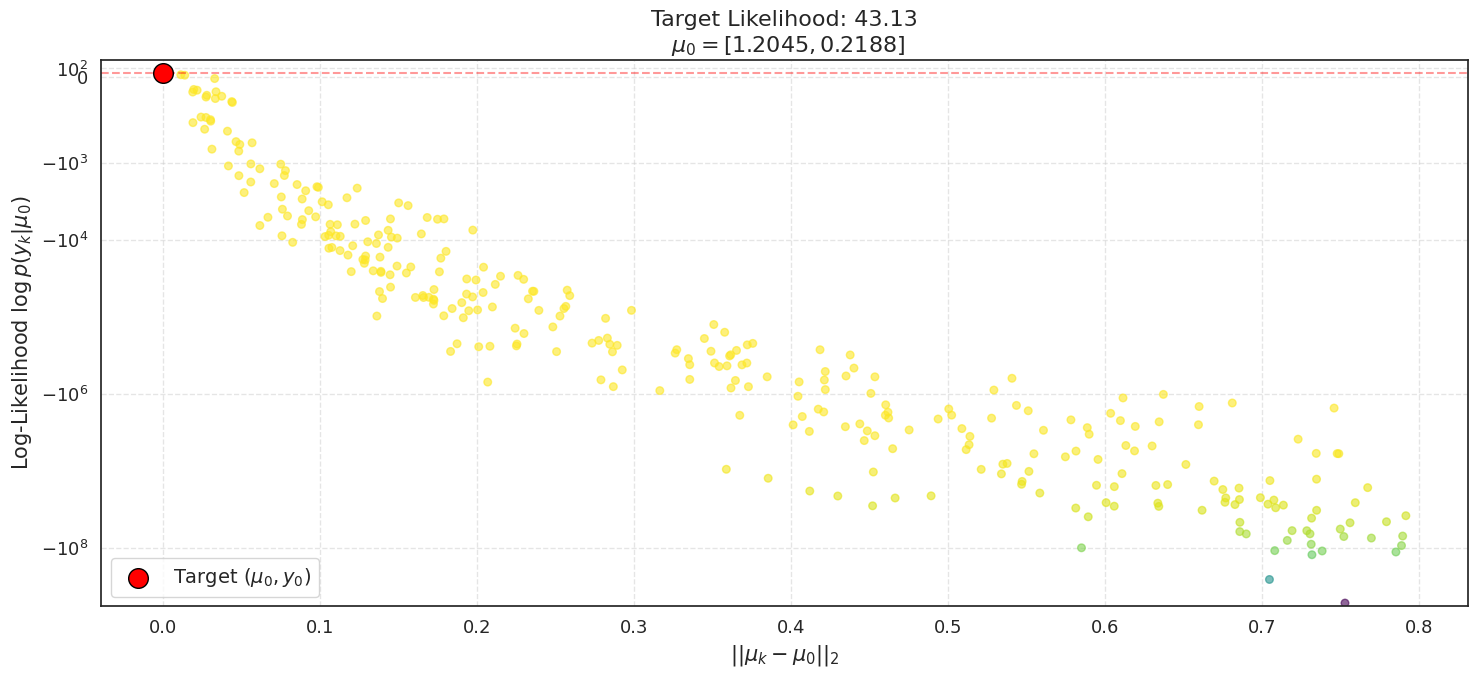

In [71]:
arr_dist, arr_like = Likelihood_Comparison_Main(flow, u, mu, V, mu_scaler, c_scaler, device,
                                    n_val, n_samples, ref_idx=test_index-1)

In [73]:
n_like = 10
print(f"First {n_like} likelihood: ")
print(np.sort(arr_like, kind='quicksort')[::-1][:n_like])
print(f"First {n_like} mu dustances: ")
print(np.sort(arr_dist)[:n_like])

First 10 likelihood: 
[  43.13181305   26.96141052   21.35385132  -17.61865997 -144.81629944
 -153.53329468 -171.67929077 -175.04336548 -213.0904541  -224.20089722]
First 10 mu dustances: 
[0.         0.01114173 0.01366614 0.01874801 0.01888157 0.01940213
 0.02155434 0.02402343 0.02634615 0.02718567]


### Comparing Distribution

In this section I'll compare the true distribution of our data, generated from the FOMsolver conditioned to a random mu (mass, delta), and the distribution of the data based on the generative model (Normalizing Flow) conditioned to the same random mu.

In [ ]:
# mu_sele: selected mu
n_replicas = 1000

u_rec = sample_same_mu(flow,
                       mu_sele, V,
                       device,
                       norm_scaler, mu_scaler, c_scaler,
                       n_replicas)

In [ ]:
# For replicas
m = torch.tensor(mu_sele[0])
d = torch.tensor(mu_sele[1])

Generating the true data for the same value $\mu_0$

In [ ]:
# Option
# 0: Gaussian Process
# 1: Linear
option = 1

mass_replica = m.repeat(n_replicas, 1)
delta_replica = d.repeat(n_replicas, 1)
g_replica_true = torch.zeros(n_replicas, V_lam.dim())
u_replica_true = torch.zeros(n_replicas, Vh.dim())

for i in range(n_replicas):

    seed_in = np.random.randint(0, 2**32 - 1)

    mass_data, delta_data, g_data, u_data, _ = FOMsampler(
        seed_in, m.numpy(), d.numpy(), option
    )

    u_replica_true[i,:] = torch.tensor(u_data)
    g_replica_true[i,:] = torch.tensor(g_data)

In [ ]:
print(f"u_replica_true shape: {u_replica_true.shape}") # True sol given same mu
print(f"u_reconstructed_rec: {u_rec.shape}") # Generated solution given same mu

u_replica_true shape: torch.Size([1000, 1922])
u_reconstructed_rec: torch.Size([1000, 1922])


Before visualizing the obtained distribution ler's compare w.r. to the Wasserstain distance how behaves the true generated samples w.r. to the one generated with the NF

In [ ]:
# Wasserstain ditsance tra i dati reali ottenuti per un dato mu e i dati generati
# dal modello per lo stesso valore di mu. Valore basso di Wasserstain distance
# implica che i dati generati con NF distano poco dalla distribuzione vera
w2_dist = Wasser_dist(u_replica_true, u_rec)
print(f"Exact Wasserstein-2 Distance (W_2): {w2_dist}")

Exact Wasserstein-2 Distance (W_2): 0.45530167554963974


What is the value of the Wasserstain distance of the all samples gnerated by the true numerical solver w.r. to the mean?

In [ ]:
# Wasserstain distance tra soluzione esatta generata per uno stesso valore di mu
# e media di tali valori. Rappresenta quanto la distribuzione "reale" dista dalla
# media. Avendi un valore così alto per la Wasserstain distance significa che la
# media in questo setting non è un buon approssimatore della distribuzione reale
Wasser_dist(u_replica_true, torch.mean(u_replica_true, axis = 0).reshape(1,-1))

np.float64(2.6244838201005014)

In [ ]:
# Wasserstain disatnce for each dimension
DIM = Vh.dim()
WD = torch.zeros(DIM)
for i in range(DIM):
    WD[i] = Wasser_dist(u_replica_true[:, i].reshape(-1,1), u_rec[:, i].reshape(-1,1))

In [ ]:
# Wasserstain distance for eache couple dimension, x and y
DIM = Vh.dim()
WD_2 = torch.zeros(DIM)
DIM_mezzi = DIM // 2
for i in range(DIM // 2):
    WD_2[2*i:2*i+2] = Wasser_dist(u_replica_true[:, [2*i,2*i+1]],
                          u_rec[:, [2*i, 2*i+1]])

(4, 2)


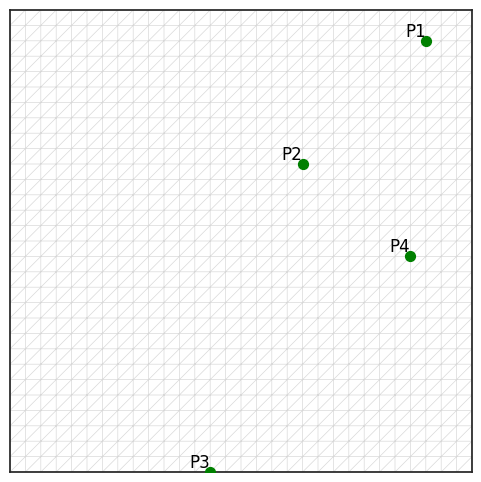

In [ ]:
dof_coordinates = Vh.tabulate_dof_coordinates()
dof_index = np.random.randint(0, Vh.dim() - 1, 4) # [2500, 770, 1040, 1844]
point_coords = dof_coordinates[dof_index]
print(point_coords.shape)

coords = mesh.coordinates()
cells = mesh.cells()

plt.figure(figsize=(6, 6))
plt.triplot(coords[:, 0], coords[:, 1], cells,
            color='gray',
            alpha=0.3,
            linewidth=0.5,
            zorder=1)

labels = ['P1', 'P2', 'P3', 'P4']
for i in range(len(labels)):
    x, y = point_coords[i, 0], point_coords[i, 1]
    plt.scatter(x, y, color='green', s=50, zorder=13)
    plt.text(x, y, labels[i], fontsize=12, color='black', ha='right', va='bottom', zorder=10)

plt.gca().set_aspect('equal')
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_2D_conditional_density(u_replica_true, u_rec, i, WD_2, label, mu_sele):

    # Riducendo 18 a 12 "schiacciamo" l'asse X, avvicinando i grafici a dei quadrati
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    col_map = 'twilight'

    # --- PRIMO GRAFICO ---
    sns.kdeplot(x=u_replica_true[:, i], y=u_replica_true[:, i+1],
                cmap=col_map, fill=True, thresh=0.05, ax=axes[0])

    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].set_xlabel('')
    axes[0].set_ylabel('')

    # --- SECONDO GRAFICO ---
    sns.kdeplot(x=u_rec[:, i], y=u_rec[:, i+1],
                cmap=col_map, fill=True, thresh=0.05, ax=axes[1])

    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

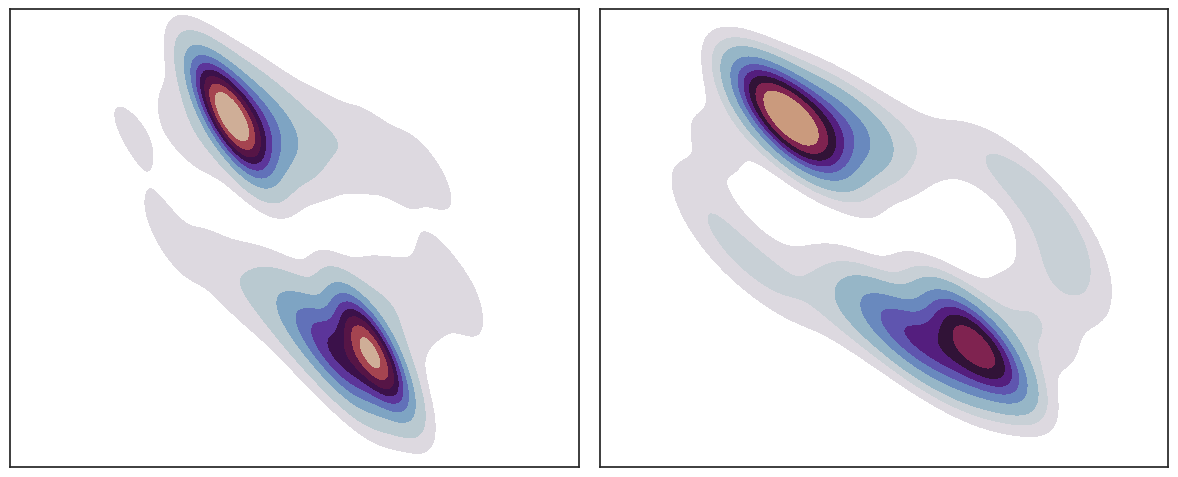

In [ ]:
innn = 0
plot_2D_conditional_density(u_replica_true, u_rec, dof_index[innn], WD_2, labels[innn], mu_sele)

In [ ]:
innnnn = 7
plot_marginal_conditional_density(u_replica_true, u_rec, WD, dof_index[innnnn], labels[innnnn], mu_sele)

In [ ]:
import numpy as np
import torch

# 1. Setup dei parametri
n_replicas = 1000
interp_steps = 5
i = 58
j = i + 1
dims = [i, j] # Questi sono i 'dims' richiesti dalla funzione di animazione

# 2. Selezione dei dati di test e setup condizione
test_index = np.random.randint(n_val, n_samples)
mu_sele = mu[test_index:test_index+1].numpy()

mu_sele_tensor = torch.tensor(mu_sele, dtype=torch.float32).to(device)
x_condition = mu_sele_tensor.repeat(n_replicas, 1)

# 3. Campionamento della traiettoria latente
latent_trajectory = flow.sample_trajectory(x_condition)

V_torch = torch.tensor(V, dtype=torch.float32).to(device)
u_trajectory = []

# 4. Ricostruzione del punto di partenza
c_prev = latent_trajectory[0]
c_unscaled = c_scaler.inverse_transform(c_prev.cpu().numpy())
u_reconstructed = torch.tensor(c_unscaled, dtype=torch.float32).to(device) @ V_torch.T
u_trajectory.append(u_reconstructed)

# 5. Loop di interpolazione (crea i passaggi intermedi)
for k in range(1, len(latent_trajectory)):
    c_next = latent_trajectory[k]
    for t in np.linspace(0, 1, interp_steps + 1)[1:]:
        c_interp_scaled = torch.lerp(c_prev, c_next, t)

        c_latent_cpu = c_interp_scaled.cpu().numpy()
        c_unscaled = c_scaler.inverse_transform(c_latent_cpu)
        u_reconstructed_step = torch.tensor(c_unscaled, dtype=torch.float32).to(device) @ V_torch.T

        u_trajectory.append(u_reconstructed_step)

    c_prev = c_next

# --- FINE ---
# Ora hai generato tutto il necessario!

## Global Performances

In [74]:
n_replicas = 200
n_generations = 200
nnn = 50

### True Data

In [ ]:
# Option:
# 0 = Gaussian Process
# 1 = Linear
option = 1

mass_test = mass[n_samples - nnn:]
delta_test = delta[n_samples - nnn:]
u_test = torch.zeros([nnn, n_replicas, Vh.dim()])

for j in range(nnn):
    if (j + 1) % 10 == 0:
        print(f"Iteration: {j+1}/{nnn}")
    for i in range(n_replicas):

        # Stochastic seed
        seed_in = np.random.randint(0, 2**32 - 1)

        _, _, _, u_sol, _ = FOMsampler(seed_in,
                                            mass_test[j].item(),
                                            delta_test[j].item(),
                                            option)
        u_test[j,i,:] = torch.tensor(u_sol)

In [ ]:
# save_path = f"{destination_folder}/u_true_test_n{n_replicas}.pt"
# torch.save(u_test, save_path)

### Generated Data

In [ ]:
u_test_gen = torch.zeros([nnn, n_replicas, Vh.dim()])

for j in range(nnn):
    if (j + 1) % 10 == 0:
        print(f"Iteration: {j+1}/{nnn}")

    current_mu = mu[n_samples - nnn + j].numpy()
    u_test_gen[j,:,:] = sample_same_mu(flow,
                          current_mu, V,
                          device,
                          norm_scaler, mu_scaler, c_scaler,
                          n_generations)

In [ ]:
# save_path = f"{destination_folder}/u_gen_test_n{n_generations}.pt"
# torch.save(u_test_gen, save_path)

### Load Data and Results

In [77]:
# These data should be upload in different way if locally - you should download first the data

# True load
filename_true = 'u_true_test_500.pth'
gdown.download(id = "18HDh9MXkXs20gbBHnqHZ2V6MqeVUI5OB", quiet=True, output = filename_true)
u_true_test = torch.load(filename_true)

# Gen load
filename_gen = 'u_gen_test_500.pth'
gdown.download(id = "1agxvMZwd8A8Up8dYVpYlitE3ngFg660T", quiet=True, output = filename_gen)
u_gen_test = torch.load(filename_gen)

In [78]:
print(f"Shape u_true_loaded: {u_true_test.shape}")
print(f"Shape u_gen_loaded: {u_gen_test.shape}")

Shape u_true_loaded: torch.Size([100, 500, 1922])
Shape u_gen_loaded: torch.Size([100, 500, 1922])


In [79]:
wasserstein_distances = []
intrinsic_distances = []

for j in range(nnn):

    U_true = u_true_test[j, :, :]
    U_gen = u_gen_test[j, :, :]

    W_j = Wasser_dist(U_true, U_gen)
    wasserstein_distances.append(W_j)

    U_mean = torch.mean(U_true, dim=0, keepdim=True)

    W_intr = Wasser_dist(U_true, U_mean)
    intrinsic_distances.append(W_intr)

    if (j + 1) % 10 == 0:
        print(f"{j+1}/{nnn} WD Model: {W_j:.6f} | WD Intrinsic: {W_intr:.6f}")

distances_array = np.array(wasserstein_distances)
intrinsic_array = np.array(intrinsic_distances)

10/50 WD Model: 0.395550 | WD Intrinsic: 3.167996
20/50 WD Model: 0.705009 | WD Intrinsic: 2.602785
30/50 WD Model: 0.628673 | WD Intrinsic: 2.851279
40/50 WD Model: 0.545307 | WD Intrinsic: 2.530901
50/50 WD Model: 0.719561 | WD Intrinsic: 2.825214


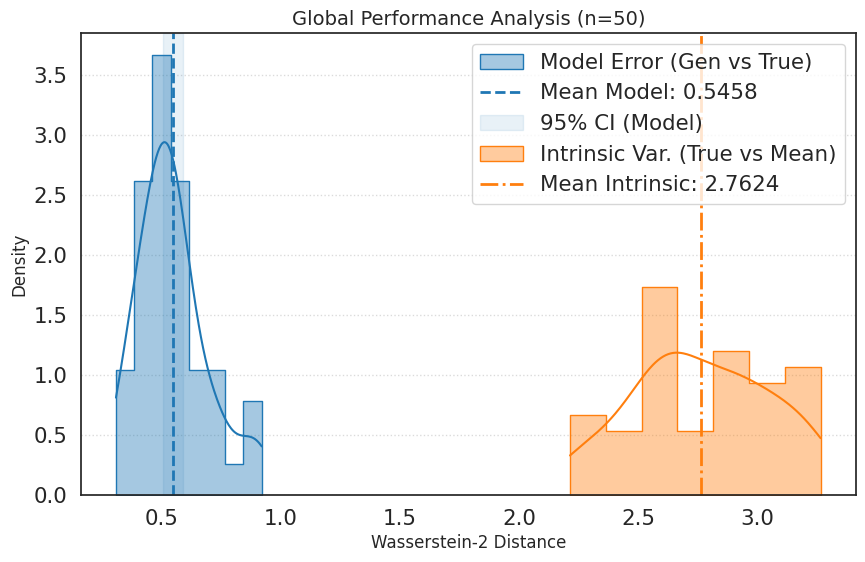

------------------------------
Sample Size:              50
Global_Mean_W2 (Model):   0.545766
Mean Intrinsic Var:       2.762406
Std Deviation (Model):    0.145412
Standard Error (Model):   0.020564
------------------------------
CI 95% on Model Mean:     [0.504441, 0.587092]
------------------------------


In [81]:
from scipy import stats

W_global_array = distances_array

mean_ws = np.mean(W_global_array)
std_ws = np.std(W_global_array, ddof=1)
sem = std_ws / np.sqrt(nnn)

ci_val = stats.t.ppf(0.975, df=nnn-1) * sem
ci_lower = mean_ws - ci_val
ci_upper = mean_ws + ci_val

mean_intr = np.mean(intrinsic_array)
std_intr = np.std(intrinsic_array, ddof=1)

plt.figure(figsize=(10, 6))

sns.histplot(W_global_array, kde=True, color='#1f77b4', stat='density',
             label='Model Error (Gen vs True)', alpha=0.4, element="step")
plt.axvline(mean_ws, color='#1f77b4', linestyle='--', linewidth=2,
            label=f'Mean Model: {mean_ws:.4f}')
plt.axvspan(ci_lower, ci_upper, color='#1f77b4', alpha=0.1, label='95% CI (Model)')

sns.histplot(intrinsic_array, kde=True, color='#ff7f0e', stat='density',
             label='Intrinsic Var. (True vs Mean)', alpha=0.4, element="step")
plt.axvline(mean_intr, color='#ff7f0e', linestyle='-.', linewidth=2,
            label=f'Mean Intrinsic: {mean_intr:.4f}')

plt.title(f"Global Performance Analysis (n={nnn})", fontsize=14)
plt.xlabel("Wasserstein-2 Distance", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

print("-" * 30)
print(f"Sample Size:              {nnn}")
print(f"Global_Mean_W2 (Model):   {mean_ws:.6f}")
print(f"Mean Intrinsic Var:       {mean_intr:.6f}")
print(f"Std Deviation (Model):    {std_ws:.6f}")
print(f"Standard Error (Model):   {sem:.6f}")
print("-" * 30)
print(f"CI 95% on Model Mean:     [{ci_lower:.6f}, {ci_upper:.6f}]")
print("-" * 30)

## Sensitivity Analysis

In [ ]:
project_path = '/content/drive/MyDrive/Normalizing_Flows_modular'
destination_folder = os.path.join(project_path, 'Elastic_Problem_Results')
filename_data = "data_linear_density_2pi.pt"
full_data_path = os.path.join(destination_folder, filename_data)

# Ricordati di runnare prima la parte su SVD

In [ ]:
file_name_u_true = f"u_true_test_n500.pt"
load_path = os.path.join(project_path, 'Elastic_Problem_Results', file_name_u_true)
u_true_test_loaded = torch.load(load_path, map_location='cpu')

print(f"Caricato u_true_test da: {load_path} | Shape: {u_true_test_loaded.shape}")

Caricato u_true_test da: /content/drive/MyDrive/Normalizing_Flows_modular/Elastic_Problem_Results/u_true_test_n500.pt | Shape: torch.Size([100, 500, 1922])


In [ ]:
import torch
import numpy as np
import os
from torch.utils.tensorboard import SummaryWriter

NUM_FLOWS = 16
HIDDEN_SIZE = 256
HIDDEN_DEPTH = 2
LR = 0.001
WD = 1e-5
EPOCHS = 200
BATCH_SIZE = 64

pairs_N = [
    (3600, 960),
    (2400, 640),
    (1200, 320),
    (480, 128),
    (240, 64)
]

### Training

In [ ]:
# print(f"--- training ({len(pairs_N)} models) ---")

# for n_train, n_val_size in pairs_N:
#     model_filename = f"NF_stokes_nt{n_train}_nv{n_val_size}.pt"
#     save_path = os.path.join(destination_folder, model_filename)

#     print(f"\nTraining Config: N_train={n_train}, N_val={n_val_size}")

#     n_split_val = n_train + n_val_size
#     train_loader, val_loader, test_loader, mu_scaler, c_scaler = LoadData(
#         mu, c, n_train, n_split_val, BATCH_SIZE=BATCH_SIZE, norm_scaler=True, shuffle=True
#     )

#     # Model
#     dim_x = mu.shape[1]
#     dim_y = c.shape[1]
#     model = NormalizingFlow(
#         dim_x, dim_y, num_flows=NUM_FLOWS, hidden_size=HIDDEN_SIZE,
#         hidden_depth=HIDDEN_DEPTH, device=device
#     ).to(device)

#     # 3. Training
#     log_dir = f"runs/exp_nt_{n_train}"
#     writer = SummaryWriter(log_dir)

#     full_train(
#         epochs=EPOCHS,
#         print_frequency=EPOCHS+1,
#         model=model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         lr=LR, weight_decacy=WD, patience=30,
#         device=device, writer=writer,
#         model_save_path=model_filename
#     )
#     writer.close()

#     if os.path.exists(model_filename):
#         checkpoint = torch.load(model_filename)
#         torch.save(checkpoint, save_path)
#         print(f"Correct saving: {save_path}")
#     else:
#         print(f"ERRORE: Il file {model_filename} non è stato creato da full_train.")

# print("\n--- Training complete ---")

### Results

In [ ]:
import torch
import numpy as np
import pandas as pd
from scipy import stats
import os
import ot
from joblib import Parallel, delayed
import multiprocessing

# Assicurati di avere test_index definito (es. test_index = 6353 o un indice valido del test set)
# index_mu0 = 6353 # Esempio se non definito precedentemente
index_mu0 = test_index

loaded_data = torch.load(full_data_path, map_location=device)
mu_full = loaded_data['mass'] # O loaded_data['mu'] se hai salvato la concatenazione
if 'mu' in loaded_data:
    mu_full = loaded_data['mu']
else:
    # Se nel file originale erano separati, li concateniamo come fatto in fase di training
    mu_full = torch.cat((loaded_data['mass'], loaded_data['delta']), 1)

mu0_raw = mu_full[index_mu0 - 1] # PyTorch tensor
mu0 = mu0_raw.cpu().numpy()

print(f"$\mu_0$ values: {mu0} (Mass, Delta) - test_index: {index_mu0}")

# n_replicas = 1000
# mass_val, delta_val = mu0[0], mu0[1]

# # Funzione wrapper per il solver elastico
# def solve_single_instance(seed_val, m, d):
#     # option=1 genera la struttura interna casuale (theta ignoto)
#     # FOMsampler restituisce (mass, delta, u_sol). A noi serve solo u_sol [2]
#     _, _, u_out = FOMsampler(seed_val, m, d, option=1)
#     return u_out

# num_cores = multiprocessing.cpu_count()

# print(f"Generating {n_replicas} true replicas using FOMsampler:")
# # Generiamo semi casuali per simulare la variabilità della struttura interna
# seeds = np.random.randint(0, 10000000, size=n_replicas)

# results = Parallel(n_jobs=num_cores, verbose=5)(
#     delayed(solve_single_instance)(seeds[i], mass_val, delta_val)
#     for i in range(n_replicas)
# )

# u_replica_true_np = np.array([res for res in results if res is not None])
# u_replica_true = torch.tensor(u_replica_true_np, dtype=torch.float32).to(device)
# print(f"True Distribution Shape: {u_replica_true.shape}")

# Assicuriamoci che V sia sul device corretto
V_torch = V.to(device) if isinstance(V, torch.Tensor) else torch.tensor(V, dtype=torch.float32).to(device)

$\mu_0$ values: [1.2044513 0.2187605] (Mass, Delta) - test_index: 6353


In [ ]:
results_local = []

# pairs_N deve essere definito come nel tuo codice originale:
# es: pairs_N = [(3600, 960), (2400, 640), ...]

for n_train, n_val_size in pairs_N:
    model_filename = f"NF_stokes_nt{n_train}_nv{n_val_size}.pt" # Nota: Mantengo "stokes" nel nome file se così li avevi salvati nel MAIN pag 5
    load_path = os.path.join(destination_folder, model_filename)

    if not os.path.exists(load_path):
        print(f"Model not found: {load_path}")
        continue

    print(f"\nLocal Analysis Model: {os.path.basename(load_path)}")

    # Load Data/Scalers per ottenere gli scaler corretti fittati su quel split
    n_split_val = n_train + n_val_size

    # Nota: mu e c devono essere disponibili nel contesto (caricati a inizio notebook)
    # Spostiamo su CPU per scikit-learn scaler come nel codice originale
    mu_cpu = mu_full.detach().cpu() if isinstance(mu_full, torch.Tensor) else mu_full
    c_cpu = c.detach().cpu() if isinstance(c, torch.Tensor) else c

    _, _, _, mu_scaler, c_scaler = LoadData(
        mu_cpu, c_cpu, n_train, n_split_val, BATCH_SIZE=64, norm_scaler=True, shuffle=True
    )

    # Load Model
    dim_x = mu_full.shape[1] # 2 per Elasticity
    dim_y = c.shape[1]       # 20 per Elasticity

    # Inizializza il modello
    model = NormalizingFlow(dim_x, dim_y, num_flows=NUM_FLOWS, hidden_size=HIDDEN_SIZE, hidden_depth=HIDDEN_DEPTH, device=device).to(device)

    checkpoint = torch.load(load_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    # Compare Distributions
    # Scaliamo i parametri mu0
    mu0_scaled_np = mu_scaler.transform(mu0.reshape(1, -1))
    mu0_tensor = torch.tensor(mu0_scaled_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        # Campioniamo n_replicas dal modello condizionato a mu0
        c_samples = model.sample(mu0_tensor.repeat(n_replicas, 1))
        c_samples_np = c_scaler.inverse_transform(c_samples.cpu().numpy())
        # Ricostruzione nello spazio fisico: u = c @ V.T
        u_rec = torch.tensor(c_samples_np, dtype=torch.float32).to(device) @ V_torch.T

        # Exact Wasserstein Distance
        w2_dist_mu0 = Wasser_dist(u_replica_true, u_rec)

    print(f"  -> Exact W2 (Dist vs Dist): {w2_dist_mu0:.4f}")

    results_local.append({
        'N_train': n_train,
        'N_val': n_val_size,
        'W2_mu0_Dist_vs_Dist': w2_dist_mu0,
        'Index_mu0': index_mu0
    })

# Save Local Results
df_local = pd.DataFrame(results_local)
csv_local_path = os.path.join(destination_folder, f"Elastic_Local_Distribution_{index_mu0}.csv")
df_local.to_csv(csv_local_path, index=False)
print(f"Local Results saved to: {csv_local_path}")

In [ ]:
# Global Performance

results_global = []
nnn = 100 # Numero di campioni del test set da analizzare
n_total_samples = mu_full.shape[0]
start_idx = n_total_samples - nnn # Prendiamo gli ultimi nnn campioni (test set)

# Carichiamo il dataset di test "True" pre-calcolato se esiste (come nel codice Stokes)
# Nel codice MAIN originale (Source 167) caricavi "u_true_test_n500.pt".
# Assumiamo che u_true_test_loaded sia disponibile.
if 'u_true_test_loaded' not in locals():
    file_name_u_true = f"u_true_test_n500.pt"
    load_path_utrue = os.path.join(destination_folder, file_name_u_true) # destination_folder definito nel MAIN
    u_true_test_loaded = torch.load(load_path_utrue, map_location='cpu')
    print(f"Loaded u_true_test from {load_path_utrue}")

for n_train, n_val_size in pairs_N:
    model_filename = f"NF_stokes_nt{n_train}_nv{n_val_size}.pt"
    load_path = os.path.join(destination_folder, model_filename)

    if not os.path.exists(load_path):
        continue

    print(f"\nGlobal Analysis Model: {os.path.basename(load_path)}")

    # Split e Scalers
    n_split_val = n_train + n_val_size
    mu_cpu = mu_full.detach().cpu() if isinstance(mu_full, torch.Tensor) else mu_full
    c_cpu = c.detach().cpu() if isinstance(c, torch.Tensor) else c

    _, _, _, mu_scaler, c_scaler = LoadData(
        mu_cpu, c_cpu, n_train, n_split_val, BATCH_SIZE=64, norm_scaler=True, shuffle=True
    )

    # Load Model
    dim_x = mu_full.shape[1]
    dim_y = c.shape[1]
    model = NormalizingFlow(dim_x, dim_y, num_flows=NUM_FLOWS, hidden_size=HIDDEN_SIZE, hidden_depth=HIDDEN_DEPTH, device=device).to(device)

    checkpoint = torch.load(load_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    w2_global_list = []

    with torch.no_grad():
        for i in range(nnn):
            # Indice corrente nel dataset completo
            current_mu_idx = start_idx + i

            # Parametri mu (Mass, Delta)
            mu_test_np = mu_full[current_mu_idx].numpy()
            mu_test_scaled = mu_scaler.transform(mu_test_np.reshape(1, -1))
            mu_test_tensor = torch.tensor(mu_test_scaled, dtype=torch.float32).to(device)

            # Generazione campioni (500 come nel codice Stokes riferimento)
            c_samples_test = model.sample(mu_test_tensor.repeat(500, 1))
            c_samples_test_np = c_scaler.inverse_transform(c_samples_test.cpu().numpy())
            u_gen_test = torch.tensor(c_samples_test_np, dtype=torch.float32).to(device) @ V_torch.T

            # Recupero Ground Truth per questo indice
            # Attenzione: l'indice 'i' qui scorre da 0 a nnn-1.
            # Assicurarsi che u_true_test_loaded corrisponda agli ultimi nnn campioni.
            # Nel codice originale stokes, u_true_test_loaded sembra contenere i campioni corrispondenti.
            u_true_single = u_true_test_loaded[i].to(device)
            if u_true_single.dim() == 1:
                u_true_single = u_true_single.reshape(1, -1)

            # Compute Metric
            d = Wasser_dist(u_true_single, u_gen_test)
            w2_global_list.append(d)

    # 4. Statistics & CI
    W_global_array = np.array(w2_global_list)
    mean_ws = np.mean(W_global_array)
    std_ws = np.std(W_global_array, ddof=1)
    sem = std_ws / np.sqrt(nnn) # Standard Error of Mean
    ci_val = stats.t.ppf(0.975, df=nnn-1) * sem # 95% Confidence Interval

    print(f"  -> Global Mean W2: {mean_ws:.4f} | CI (95%): +/- {ci_val:.4f}")

    results_global.append({
        'N_train': n_train,
        'N_val': n_val_size,
        'Global_Mean_W2': mean_ws,
        'Global_CI_95': ci_val,
        'Global_Std': std_ws
    })

# Save Global Results
df_global = pd.DataFrame(results_global)
csv_global_path = os.path.join(destination_folder, f"Elastic_Global_CI_{index_mu0}.csv")
df_global.to_csv(csv_global_path, index=False)
print(f"Global Results saved to: {csv_global_path}")